# Tutorial showing usage of pretrained autoencoder models 
This tutorial focus on the usage of pretrained models for scRNASeq data and provided under: 
https://huggingface.co/collections/autoencodix/acx-pretrained-models 

### Download the model files
In this tutorial we will use the a Ontix model with explainable latent space based on ontologies generated with Gemini3ProPreview:

https://huggingface.co/autoencodix/Ontix-Dim24-Gemini3ProPreview



In [1]:
import os
from huggingface_hub import snapshot_download

model_name = "Ontix-Dim24-Gemini3ProPreview"
repo_id = f"autoencodix/{model_name}"
target_folder = f"./acx_pretrained_models/{model_name}"
private = True  # Set to True if the repository is private
if private:
	token = os.environ.get("HF_TOKEN")
	if token is None:
		raise EnvironmentError(
			"HF_TOKEN is not set."
		)
else:
	token = None

local_dir = snapshot_download(
    repo_id=repo_id,
    local_dir=target_folder,
    local_dir_use_symlinks=False,
    token=token,  # uncomment if repo is private
)

print(f"All repo files downloaded to: {local_dir}")

/home/ewald/Github/autoencodix_package/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:979: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

All repo files downloaded to: /home/ewald/Github/autoencodix_package/Tutorials/DeepDives/acx_pretrained_models/Ontix-Dim24-Gemini3ProPreview


## Download and prepare example scRNASeq data
To show how to use scRNASeq with pretrained models, we will download example data via the CZ cellxgene census database:

https://chanzuckerberg.github.io/cellxgene-census/

As an example we will download a specific cell type (respiratory basal cell) from lung tissue for both normal samples and from samples with cystic fibrosis

In [ ]:
import pandas as pd

# Get the gene space of the autoencoder to efficiently download only the necessary genes
ont_file = f"./acx_pretrained_models/{model_name}/ontology/Dim24_Gemini3ProPreview_ontology_task__ensembl_level2.tsv"
ont_features = pd.read_csv(ont_file, sep='\t', usecols=[0], header=None)
ont_features.columns = ['feature_id']
var_value_filter="feature_id in [" + ", ".join(f'"{gene}"' for gene in list(ont_features.feature_id)) + "]"

# Define the observation filter to get only the relevant cell types, tissues, and diseases
obs_value_filter = "tissue_general == 'lung' and disease in ['cystic fibrosis', 'normal'] and cell_type in ['respiratory basal cell'] and is_primary_data == True"

In [ ]:
import cellxgene_census

# TODO Retrieval even for 20,000 samples is very slow (nearly 30min)
with cellxgene_census.open_soma() as census:
    adata = cellxgene_census.get_anndata(
        census = census,
        organism = "Homo sapiens",
        var_value_filter = var_value_filter,
        obs_value_filter = obs_value_filter,
    )


adata

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
/home/ewald/Github/autoencodix_package/.venv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/home/ewald/Github/autoencodix_package/.venv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:67: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 19908 × 8189
    obs: 'soma_joinid', 'dataset_id', 'assay', 'assay_ontology_term_id', 'cell_type', 'cell_type_ontology_term_id', 'development_stage', 'development_stage_ontology_term_id', 'disease', 'disease_ontology_term_id', 'donor_id', 'is_primary_data', 'observation_joinid', 'self_reported_ethnicity', 'self_reported_ethnicity_ontology_term_id', 'sex', 'sex_ontology_term_id', 'suspension_type', 'tissue', 'tissue_ontology_term_id', 'tissue_type', 'tissue_general', 'tissue_general_ontology_term_id', 'raw_sum', 'nnz', 'raw_mean_nnz', 'raw_variance_nnz', 'n_measured_vars'
    var: 'soma_joinid', 'feature_id', 'feature_name', 'feature_type', 'feature_length', 'nnz', 'n_measured_obs'

Importantly, models have been trained on log1p normalized counts. We do this manually and then create a data package for autoencodix:

In [39]:
import scanpy 
from autoencodix.data._numeric_dataset import NumericDataset
from autoencodix.data._datasetcontainer import DatasetContainer
from autoencodix.configs.ontix_config import OntixConfig

# scanpy.pp.log1p(adata, copy=False)

test_dataset = NumericDataset(
			data=adata.X, # the normalized expression data per cell
			config=OntixConfig(), # Empty placeholder
			sample_ids=adata.obs.index, # cell ids
			metadata=adata.obs.loc[adata.obs.index,:], # cell annotation data for plotting etc.
			split_indices=None, # Empty placeholder
			feature_ids=adata.var.feature_id, # Gene ids
		)

acx_container = DatasetContainer(train=None, valid=None, test=test_dataset)

# Save the container 
import pickle
# Create directory
os.makedirs("./TutData", exist_ok=True)

with open(f"./TutData/scRNASeq_cystic_fibrosis_{model_name}.pkl", "wb") as f:
	pickle.dump(acx_container, f)

## Calculate embeddings using a pretrained model
Now we can load the data and a model to calculate embeddings and visualize them

In [1]:
model_name = "Ontix-Dim24-Gemini3ProPreview"
import autoencodix as acx
import pickle

ontix_file_path = f"./acx_pretrained_models/{model_name}/large_ontix_final_model_Dim24_Gemini3ProPreview_ontology_task__.pkl"

print("Loading trained model ...")
loaded_ontix = acx.Ontix.load(file_path=ontix_file_path)
loaded_ontix._trainer._config.save_vram = True  # Enable memory saving for prediction

print("Load test data container ...")
with open(f"./TutData/scRNASeq_cystic_fibrosis_{model_name}.pkl", "rb") as f:
	acx_container = pickle.load(f)

print("Calculate embeddings ...")
result = loaded_ontix.predict(data=acx_container)


Loading trained model ...
Attempting to load a pipeline from acx_pretrained_models/Ontix-Dim24-Gemini3ProPreview/large_ontix_final_model_Dim24_Gemini3ProPreview_ontology_task__.pkl...
Pipeline object loaded successfully. Actual type: Ontix
Preprocessor loaded successfully.
Load test data container ...
Calculate embeddings ...


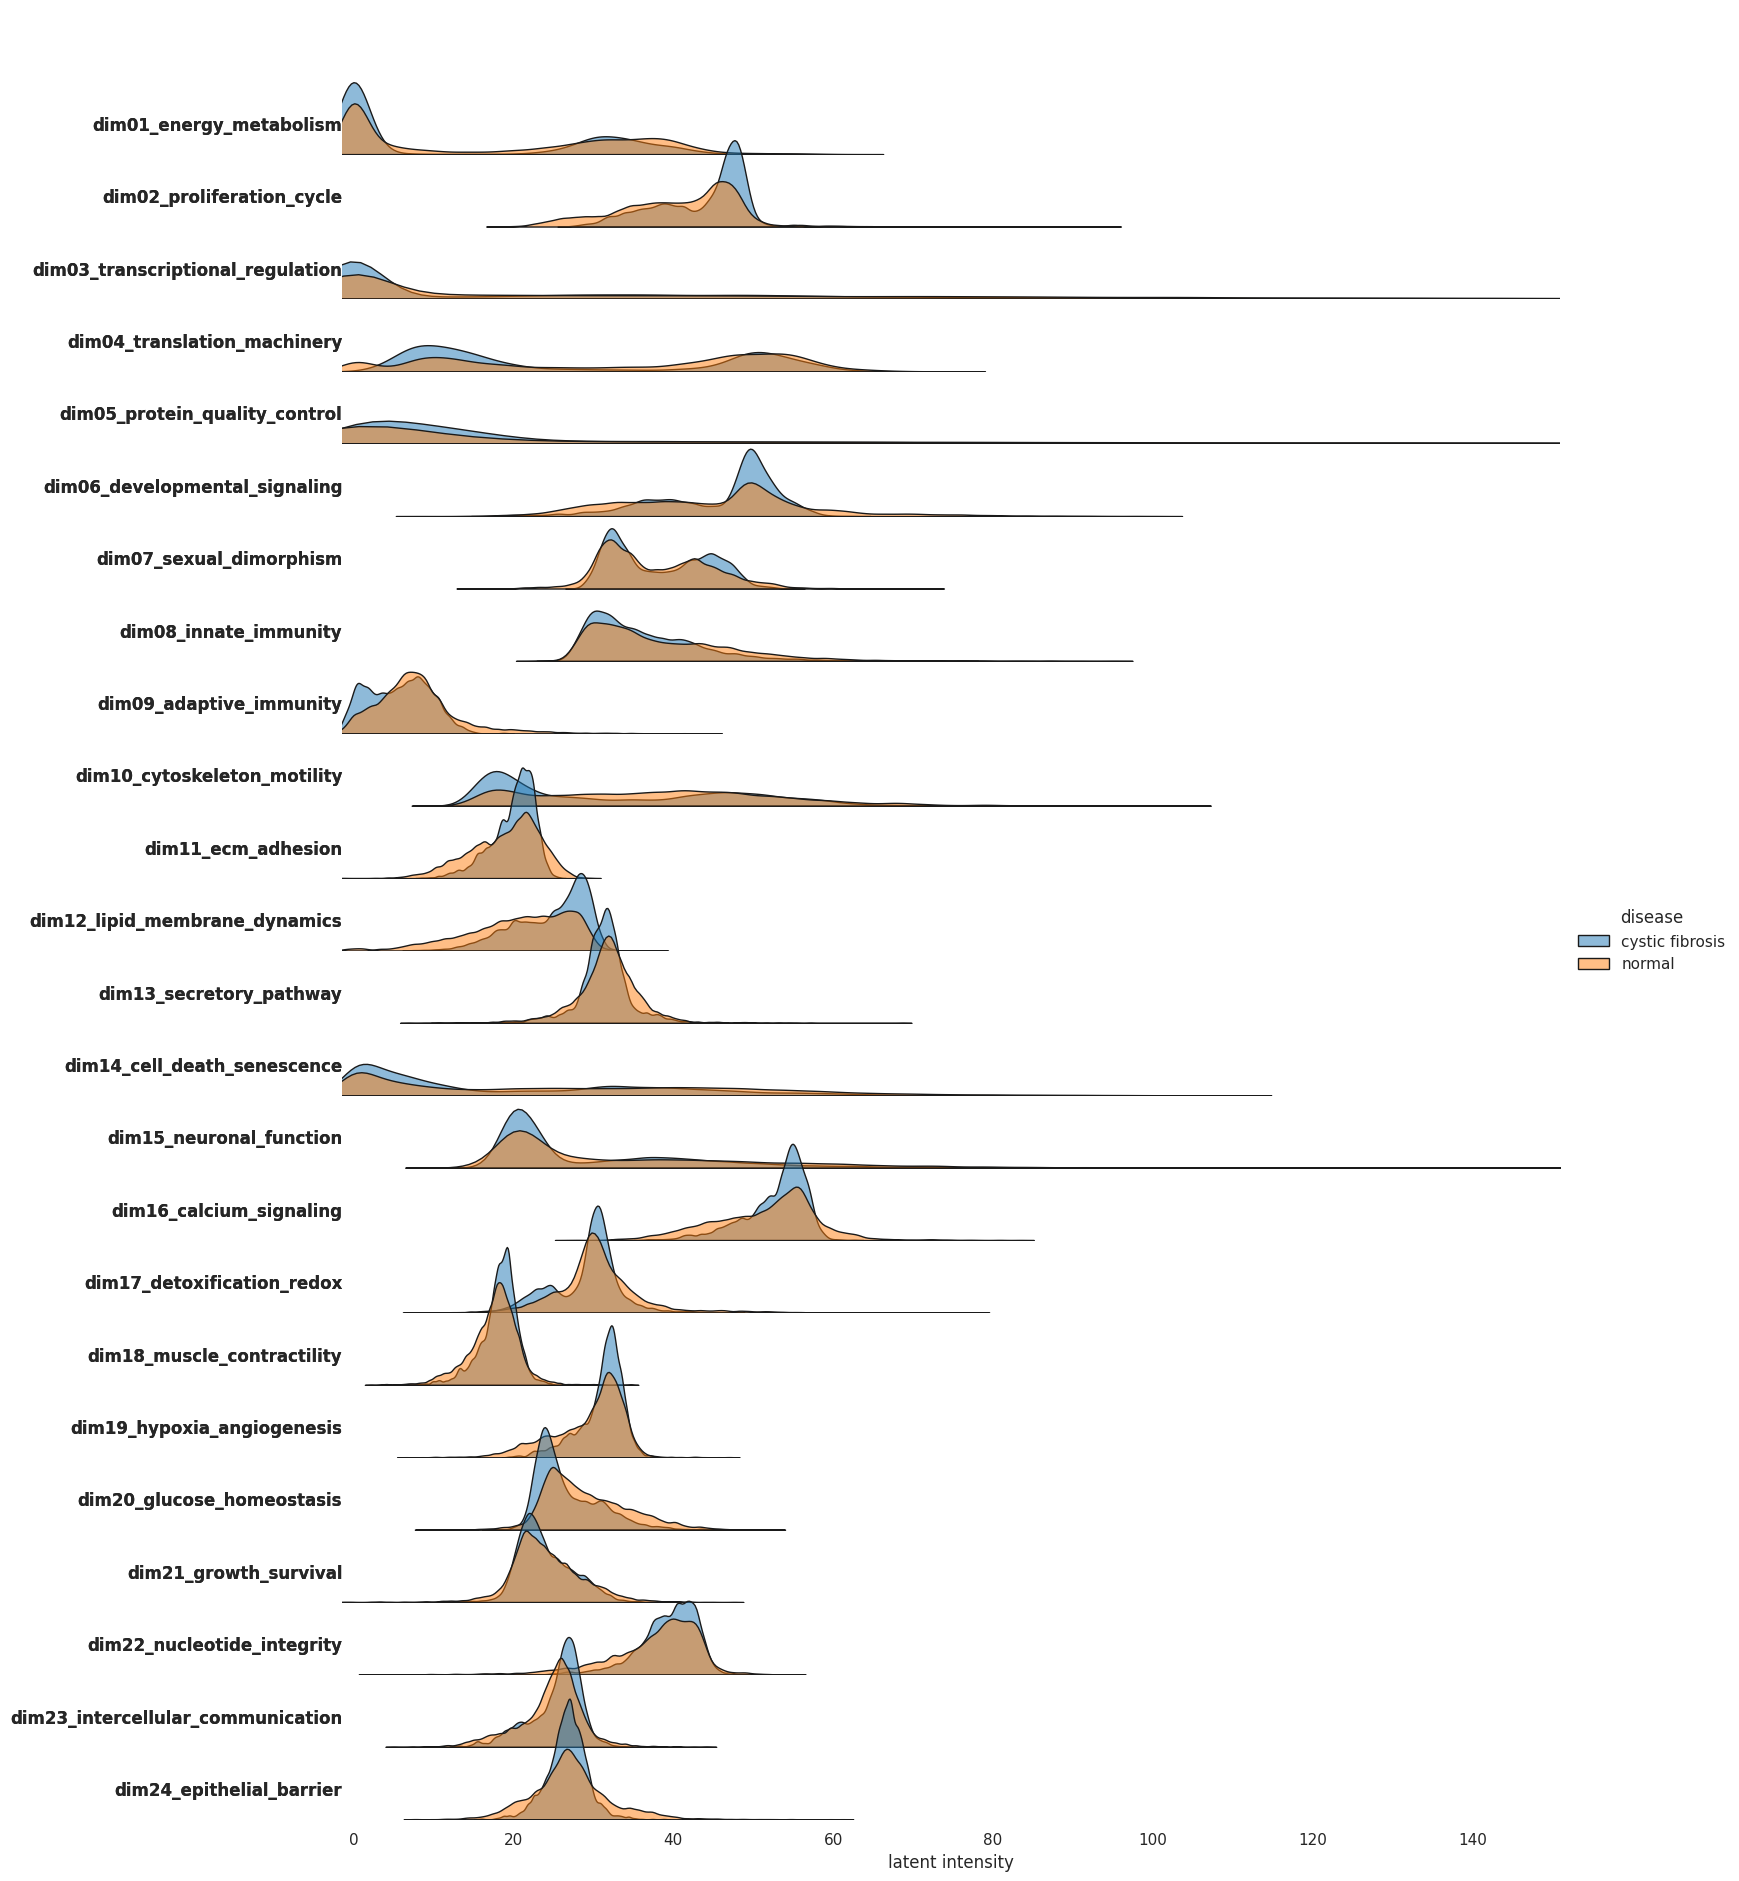

In [2]:
# Create a latent space visualization
loaded_ontix.visualizer.show_latent_space(
	result=result,
	plot_type="Ridgeline",
	param=['disease'], 
	split="test",
)

## Using explain() functionality for xAI
We can leverage posthoc xAI and LLMs to get a better understanding which genes and processes drive differences of classes like cystic fibrosis vs. normal cells

For this we will firstly determine which latent dimensions show highest class separation: 

In [3]:
# Perform Linear Discriminant Analysis (LDA) to find the latent dimension that best separates the groups
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_validate

import numpy as np
import pandas as pd

anno_col = "disease"
groups_list = [
	"cystic fibrosis",
	"normal"
]
# Get the latent space as df
df_latent = loaded_ontix.result.get_latent_df(split="test", epoch=-1)

scores = {}
# for each latent dimension
for latent_dim in df_latent.columns:
	lda = LinearDiscriminantAnalysis()
	X = df_latent[latent_dim].values.reshape(-1, 1)
	y = loaded_ontix.result.new_datasets.test.metadata[anno_col].values
	# Reduce x and y to only include samples from the groups of interest
	mask = np.isin(y, groups_list)
	X = X[mask]
	y = y[mask]
	metric = "roc_auc_ovo"
 	# Do CV-5 fold cross-validation and calculate the AUC-ROC score for this latent dimension
	scores[latent_dim] = cross_validate(lda, X, y, cv=5, scoring=metric, return_train_score=True, n_jobs=-1)

scores_df = pd.DataFrame({
	'latent_dim': list(scores.keys()),
	'test_score_mean': [scores[ld]['test_score'].mean() for ld in scores.keys()],
	'test_score_std': [scores[ld]['test_score'].std() for ld in scores.keys()],
	'train_score_mean': [scores[ld]['train_score'].mean() for ld in scores.keys()],
	'train_score_std': [scores[ld]['train_score'].std() for ld in scores.keys()],
})
scores_df = scores_df.sort_values(by='test_score_mean', ascending=False)
scores_df

,latent_dim,test_score_mean,test_score_std,train_score_mean,train_score_std
11,dim12_lipid_membrane_dynamics,0.684443,0.016686,0.684561,0.004189
19,dim20_glucose_homeostasis,0.648148,0.017045,0.648018,0.004319
1,dim02_proliferation_cycle,0.634525,0.031151,0.634068,0.007971
8,dim09_adaptive_immunity,0.617355,0.058945,0.617226,0.014553
0,dim01_energy_metabolism,0.600353,0.046991,0.599658,0.011996
18,dim19_hypoxia_angiogenesis,0.594299,0.050348,0.593731,0.012719
9,dim10_cytoskeleton_motility,0.593909,0.033176,0.593460,0.008304
13,dim14_cell_death_senescence,0.589042,0.061894,0.588580,0.015499
2,dim03_transcriptional_regulation,0.576627,0.038311,0.576097,0.009523
21,dim22_nucleotide_integrity,0.571829,0.030103,0.571923,0.007561


The highest seperation of cystic fibrosis vs normal is observed for `dim12_lipid_membrane_dynamics` and `dim20_glucose_homeostasis`. Now let's calculatue the feature (gene) attribution to those dimensions and identify potential marker genes and get a functional analyses via an LLM.

To use the openrouter API store make yor API key available as environment variable `OPENROUTER_PREMIUM_API_KEY`. Accordingly, using SCADS-LLM server with API key under `SCADS_LLM_API_KEY`. See also `LLM_Setup.md`.

In [4]:
selected_dim = list(scores_df.iloc[0:2]['latent_dim'].values) # Top latent dimensions with highest AUC-ROC score for separating the groups
top_n_genes = 15 # Number of top contributing genes per latent dimension

latent_contributions = loaded_ontix.explain(
    split="test",
    method="IntegratedGradients", # "DeepLiftShap" or "IntegratedGradients"
    n_subset=400, # Randomly sample in input and baseline space for computational efficiency
    sel_latent_dim=selected_dim, # Or specify a single latent dimension to explain    
	input_type="grouped", # We will test group 'cystic fibrosis' (input) vs. 'normal' (baseline)
	input_group=groups_list[0], # "cystic fibrosis" 
	baseline_type="random",
	baseline_group=groups_list[1], # "normal"
	anno_col=anno_col,
	llm_explain=True, 	# Explain biological functions of the contributing genes using a LLM
	llm_client="openrouter",
	llm_model="google/gemini-3.1-flash-lite-preview",
	# llm_client="scads-llm",
	# llm_model="google/gemma-4-31b-it",
	# llm_model="alias-ha",
	top_n_genes=top_n_genes,
)

Start feature attribution calculation
Calculating attributions for latent dimension: 11
Calculating attributions for latent dimension: 19
Start LLM explanation generation
Explaining latent dimension dim12_lipid_membrane_dynamics with LLM...
Explaining latent dimension dim20_glucose_homeostasis with LLM...
Saved explanations to: /home/ewald/Github/autoencodix_package/Tutorials/DeepDives/latent_explanations.md


The LLM-based verbal explaination and summary is stored as a markdown file:

In [5]:
from pathlib import Path
from IPython.display import Markdown, display

md_path = Path("latent_explanations.md")
display(Markdown(md_path.read_text(encoding="utf-8")))

# Latent Dimension dim12_lipid_membrane_dynamics

## Most influential genes
ENSG00000205542, ENSG00000019582, ENSG00000124614, ENSG00000185885, ENSG00000130522, ENSG00000213741, ENSG00000008988, ENSG00000170345, ENSG00000089157, ENSG00000122026, ENSG00000133639, ENSG00000130066, ENSG00000132002, ENSG00000125148, ENSG00000243678

## TLDR
This latent dimension captures the regulation of neuronal synaptic transmission, vesicle trafficking, and calcium-dependent signaling pathways critical for synaptic plasticity.

## Details

### Dominant Biological Themes

The gene set is highly enriched for proteins involved in synaptic vesicle cycling, neurogenesis, and neurotransmitter secretion, specifically focusing on calcium-sensing, exocytosis, and ion channel modulation.

### Mechanistic Hypotheses

- The dimension represents the functional state of neuronal synaptic vesicle priming and release, governed by calcium-dependent machinery.

- The dimension captures the regulatory program controlling neuronal development, axonal growth, and the assembly of synaptic architecture.

- The dimension reflects transcriptional programs modulating neuronal excitability through the coordinated expression of ion binding proteins and specialized membrane trafficking complexes.

### Summary of Pathways/Processes

Involved processes include synaptic vesicle cycle (GO:0006904), regulation of calcium ion transport (GO:0006816), chemical synaptic transmission (GO:0007268), axon guidance (GO:0007411), and protein components of the presynaptic active zone and post-synaptic densities.


---

# Latent Dimension dim20_glucose_homeostasis

## Most influential genes
ENSG00000185885, ENSG00000243678, ENSG00000111640, ENSG00000170296, ENSG00000075624, ENSG00000130522, ENSG00000067225, ENSG00000149925, ENSG00000008988, ENSG00000213741, ENSG00000240972, ENSG00000198886, ENSG00000089157, ENSG00000087460, ENSG00000198763

## TLDR
This latent dimension captures the regulatory program of oxidative phosphorylation and mitochondrial respiratory chain integrity in metabolically active cells.

## Details

### Dominant Biological Themes

The gene set is dominated by mitochondrial structural components and enzymes essential for the electron transport chain, specifically encoding subunits for Complex I (NDUFs) and Complex IV (COX), indicating a metabolic state defined by mitochondrial biogenesis or oxidative efficiency.

### Mechanistic Hypotheses

- The dimension represents a coordinated transcriptional program governing the assembly and maintenance of mitochondrial respiratory chain complexes, marking cells with high energetic demands.

- The dimension reflects a response to metabolic stress or nutrient deprivation that triggers mitochondrial turnover or compensatory upregulation of oxidative phosphorylation machinery.

### Summary of Pathways/Processes

The genes are heavily enriched in oxidative phosphorylation (KEGG), mitochondrial respiratory chain complex assembly (GO:0032981), and aerobic respiration processes, specifically pointing toward mitochondrial inner membrane functions.


---


## Using the .generate() functionality for synthetic data generation
Leveraging our pretrained models we can sample from the latent space artificial cells. 

We can do this either randomly across the whole latent space or from pre-defined points of the latent space. 

We will do here the latter by calculating the mean of our cystic fibrosis cells for each latent dimension and generate 1000 synthetic cells from this point of the latent space.

In [9]:
df_latent_cf = df_latent.loc[
	result.new_datasets.test.metadata.disease == 'cystic fibrosis',
 :
]

latent_prior_means = df_latent_cf.mean()

# Generate 1000 latent prior samples based on means and some noise
num_samples = 1000
noise = np.random.normal(0, 0.1, (num_samples, len(latent_prior_means)))
synthetic_latent = np.tile(latent_prior_means.values, (num_samples, 1)) + noise

In [17]:
# Generate reconstructions (gene expression) from the synthetic latent samples
generated_reconstructions = loaded_ontix.generate(latent_prior=synthetic_latent)
print("Generated reconstructions shape:", generated_reconstructions.shape)

Generated reconstructions shape: torch.Size([1000, 8189])
